In [3]:
import pandas as pd
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report, precision_score, recall_score
import matplotlib.pyplot as plt
import numpy as np
import itertools
import seaborn as sns
from sklearn.manifold import TSNE
import pickle as pkl
from sklearn.decomposition import PCA

In [4]:
curve_df = pd.read_hdf('../data/data.h5', key='curve_data')
sample_info = pd.read_hdf('../data/data.h5', key='sample_info')
igi_gene_call = pd.read_hdf('../data/data.h5', key='igi_gene_call')
groundtruth_df = pd.read_csv('../data/groundtruth_df.csv')
groundtruth_df.loc[:,'groundtruth_label'] = groundtruth_df.groundtruth.replace({-1:0, 1:1})
groundtruth_df.loc[:,'encoded_igi_call'] = groundtruth_df.igi_call.replace({'Negative':0, 'Positive':1})
# val_pred = pd.read_csv('../data/model_outputs/fusion_val_pred_df.csv')
test_pred = pd.read_csv('../data/model_outputs/fusion_test_pred_df.csv')

In [5]:
gru_val_pred = pd.read_csv('../data/model_outputs/gru_val_pred_df.csv') #seq_only_val_pred_df.csv')
gru_test_pred = pd.read_csv('../data/model_outputs/gru_test_pred_df.csv') #seq_only_test_pred_df.csv')

In [6]:
# val_pred = val_pred[val_pred.curve_idx.isin(gru_val_pred.curve_idx)]
test_pred = test_pred[test_pred.curve_idx.isin(gru_test_pred.curve_idx)]

In [7]:
groundtruth_df.head()

,curve_idx,target,sample_type,sample_id,igi_call,cycle_no,Fn,rn,groundtruth,split,groundtruth_label,encoded_igi_call
0,24933,S gene,Negative Control (qPCR),S252611,Negative,1,195418.72,195418.718750,-1,train,0,0
1,24933,S gene,Negative Control (qPCR),S252611,Negative,2,195288.33,195288.328125,-1,train,0,0
2,24933,S gene,Negative Control (qPCR),S252611,Negative,3,194651.67,194651.671875,-1,train,0,0
3,24933,S gene,Negative Control (qPCR),S252611,Negative,4,194355.02,194355.015625,-1,train,0,0
4,24933,S gene,Negative Control (qPCR),S252611,Negative,5,194165.97,194165.968750,-1,train,0,0


In [8]:
join_df = (curve_df
           .merge(sample_info, how='inner', on=['well_position','pcr_plate'])
           .merge(igi_gene_call, how ='inner', on=['pcr_plate','sample_id','target']))


In [9]:
# val_pred_df = (groundtruth_df.loc[groundtruth_df.split == 'val', ['curve_idx','groundtruth_label','encoded_igi_call']].drop_duplicates()
#            .merge(val_pred, how='inner', on = 'curve_idx'))
# val_pred_df = val_pred_df.rename(columns={'prob':'outputs'})
# test_pred_df = (groundtruth_df.loc[groundtruth_df.split == 'test', ['curve_idx','groundtruth_label','encoded_igi_call']].drop_duplicates()
#            .merge(test_pred, how='inner', on = 'curve_idx'))
test_pred_df = (groundtruth_df[['curve_idx','groundtruth_label','encoded_igi_call']].drop_duplicates()
           .merge(test_pred, how='inner', on = 'curve_idx'))
test_pred_df = test_pred_df.rename(columns={'prob':'outputs'})


In [18]:
val_auc = roc_auc_score(val_pred_df.groundtruth_label, val_pred_df.outputs)
val_fpr, val_tpr, val_thresholds = roc_curve(val_pred_df.groundtruth_label, val_pred_df.outputs)

val_igi_auc = roc_auc_score(val_pred_df.groundtruth_label, val_pred_df.encoded_igi_call)
val_igi_fpr, val_igi_tpr, val_igi_thresholds = roc_curve(val_pred_df.groundtruth_label, val_pred_df.encoded_igi_call)

plt.figure(figsize=(8, 6))
plt.plot(val_fpr, val_tpr, color='blue', lw=2, label='Model ROC curve (AUC = {:.2f})'.format(val_auc))
plt.plot(val_igi_fpr, val_igi_tpr, color='red', lw=2, label='IGI ROC curve (AUC = {:.2f})'.format(val_igi_auc))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve on Validation Set')
plt.legend(loc='lower right')
plt.show()


NameError: name 'val_pred_df' is not defined

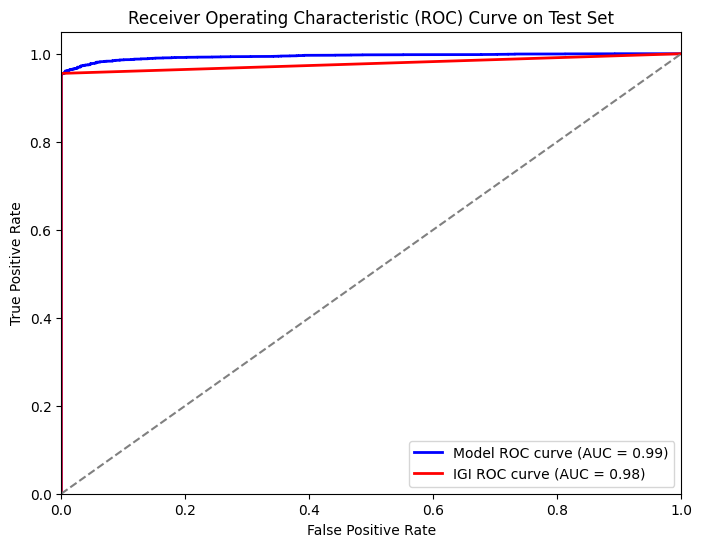

In [19]:
test_auc = roc_auc_score(test_pred_df.groundtruth_label, test_pred_df.outputs)
test_fpr, test_tpr, test_thresholds = roc_curve(test_pred_df.groundtruth_label, test_pred_df.outputs)

test_igi_auc = roc_auc_score(test_pred_df.groundtruth_label, test_pred_df.encoded_igi_call)
test_igi_fpr, test_igi_tpr, test_igi_thresholds = roc_curve(test_pred_df.groundtruth_label, test_pred_df.encoded_igi_call)

plt.figure(figsize=(8, 6))
plt.plot(test_fpr, test_tpr, color='blue', lw=2, label='Model ROC curve (AUC = {:.2f})'.format(test_auc))
plt.plot(test_igi_fpr, test_igi_tpr, color='red', lw=2, label='IGI ROC curve (AUC = {:.2f})'.format(test_igi_auc))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve on Test Set')
plt.legend(loc='lower right')
plt.show()


In [18]:
igi_recall = recall_score(val_pred_df.groundtruth_label, val_pred_df.encoded_igi_call)
igi_precision = precision_score(val_pred_df.groundtruth_label, val_pred_df.encoded_igi_call)
igi_tn = sum((val_pred_df.groundtruth_label == val_pred_df.encoded_igi_call) & (val_pred_df.encoded_igi_call == 0))

# print('IGI true positive:', igi_tp)
print('IGI precision score:', igi_precision)
print('IGI recall score:', igi_recall)
print('IGI true negatives:', igi_tn)

IGI precision score: 0.9989952273298166
IGI recall score: 0.9562394806443857
IGI true negatives: 445


In [19]:
# Define the number of true negatives and false negatives for different thresholds
# Replace these values with your actual data
thresholds = np.linspace(0.1, 1, 1000)
tnrs, precisions, recalls = [], [], []
for thres in thresholds:
    pred = 1*(val_pred_df.outputs >= thres)
    tnrs.append(sum((val_pred_df.groundtruth_label == 0) & (val_pred_df.groundtruth_label == pred)))
    precisions.append(precision_score(val_pred_df.groundtruth_label, pred, zero_division=0))
    recalls.append(recall_score(val_pred_df.groundtruth_label, pred))

threshold_idx = tnrs.index(445)
matched_thres = thresholds[threshold_idx]
print('Threshold to match IGI true negatives:', matched_thres)
print('With matching threshold, model precision:', precisions[threshold_idx])
print('With matching threshold, model recall:', recalls[threshold_idx])

Threshold to match IGI true negatives: 0.9099099099099099
With matching threshold, model precision: 0.9989964877069744
With matching threshold, model recall: 0.9574416927145949


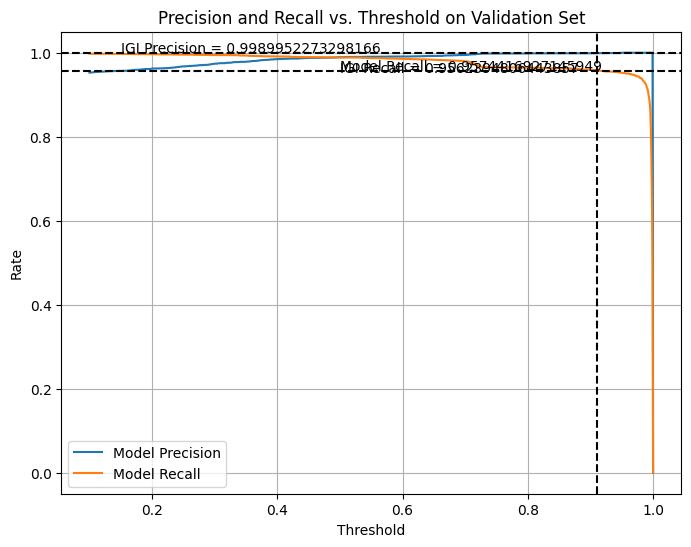

In [20]:



# Create a plot
plt.figure(figsize=(8, 6))
plt.plot(thresholds, precisions, label='Model Precision')
plt.plot(thresholds, recalls, label='Model Recall')
plt.axhline(igi_precision, color = 'black', linestyle='--')
plt.annotate(f'IGI Precision = {igi_precision}', xy=(0.1, igi_precision), xytext=(0.15, 1))
plt.axvline(thresholds[threshold_idx], color = 'black', linestyle='--')
plt.axhline(recalls[threshold_idx], color = 'black', linestyle='--')
plt.annotate(f'Model Recall = {recalls[threshold_idx]}', xy=(0.1, recalls[threshold_idx]), xytext=(0.5, recalls[threshold_idx]*1.001))
plt.annotate(f'IGI Recall = {igi_recall}', xy=(0.1, recalls[threshold_idx]), xytext=(0.5, recalls[threshold_idx]*0.996))
plt.xlabel("Threshold")
plt.ylabel("Rate")
plt.title("Precision and Recall vs. Threshold on Validation Set")
plt.legend(loc='lower left')
plt.grid(True)
plt.show()


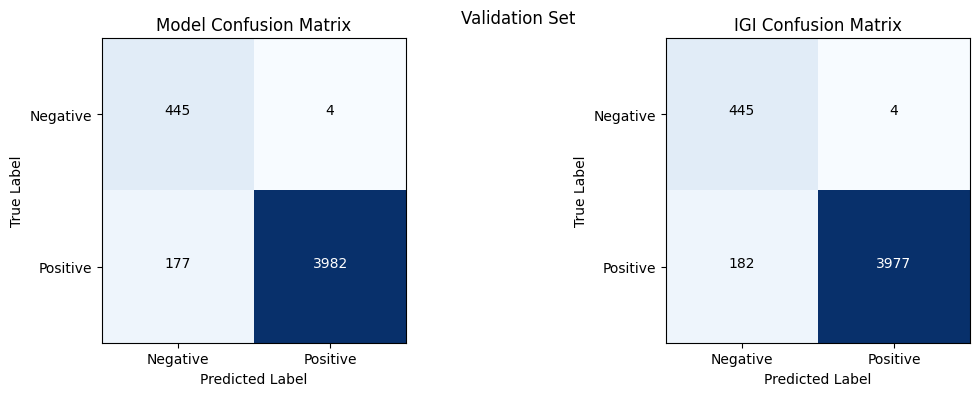

In [21]:
matched_preds = 1*(val_pred_df.outputs >= matched_thres)
# Calculate the confusion matrix
cm1 = confusion_matrix(val_pred_df.groundtruth_label, matched_preds)
cm2 = confusion_matrix(val_pred_df.groundtruth_label, val_pred_df.encoded_igi_call)

# Define class labels (replace with your class labels)
class_labels = ["Negative", "Positive"]

# Create a heatmap of the confusion matrix
fig, axes = plt.subplots(1,2, figsize=(12,4))

axes[0].imshow(cm1, interpolation='nearest', cmap=plt.cm.Blues)
axes[0].set_title("Model Confusion Matrix")
axes[0].set_xticks(np.arange(len(class_labels)))
axes[0].set_yticks(np.arange(len(class_labels)))
axes[0].set_xticklabels(class_labels)
axes[0].set_yticklabels(class_labels)

thresh = cm1.max() / 2.
for i, j in itertools.product(range(cm1.shape[0]), range(cm1.shape[1])):
    axes[0].text(j, i, format(cm1[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm1[i, j] > thresh else "black")

axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Plot the second confusion matrix
axes[1].imshow(cm2, interpolation='nearest', cmap=plt.cm.Blues)
axes[1].set_title("IGI Confusion Matrix")
axes[1].set_xticks(np.arange(len(class_labels)))
axes[1].set_yticks(np.arange(len(class_labels)))
axes[1].set_xticklabels(class_labels)
axes[1].set_yticklabels(class_labels)

thresh = cm2.max() / 2.
for i, j in itertools.product(range(cm2.shape[0]), range(cm2.shape[1])):
    axes[1].text(j, i, format(cm2[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm2[i, j] > thresh else "black")

axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

fig.tight_layout()
fig.suptitle('Validation Set')
plt.show()


In [22]:
val_pred_df.loc[:,'matched_pred'] = matched_preds
print('Model confusion matrix')
print(classification_report(val_pred_df.groundtruth_label, round(val_pred_df.matched_pred)))
print('IGI Model confusion matrix')
print(classification_report(val_pred_df.groundtruth_label, val_pred_df.encoded_igi_call))

Model confusion matrix
              precision    recall  f1-score   support

           0       0.72      0.99      0.83       449
           1       1.00      0.96      0.98      4159

    accuracy                           0.96      4608
   macro avg       0.86      0.97      0.90      4608
weighted avg       0.97      0.96      0.96      4608

IGI Model confusion matrix
              precision    recall  f1-score   support

           0       0.71      0.99      0.83       449
           1       1.00      0.96      0.98      4159

    accuracy                           0.96      4608
   macro avg       0.85      0.97      0.90      4608
weighted avg       0.97      0.96      0.96      4608



In [23]:
diff_df = val_pred_df.loc[val_pred_df.encoded_igi_call != val_pred_df.matched_pred]
print('Number of different curves:', diff_df.shape[0])
diff_df.head()

Number of different curves: 89


,curve_idx,groundtruth_label,encoded_igi_call,outputs,matched_pred
74,13349,0,0,0.947952,1
285,103252,1,0,0.971592,1
434,45626,1,1,0.900601,0
509,7304,1,1,0.078598,0
511,7108,1,1,0.834197,0


29135
86000
86384


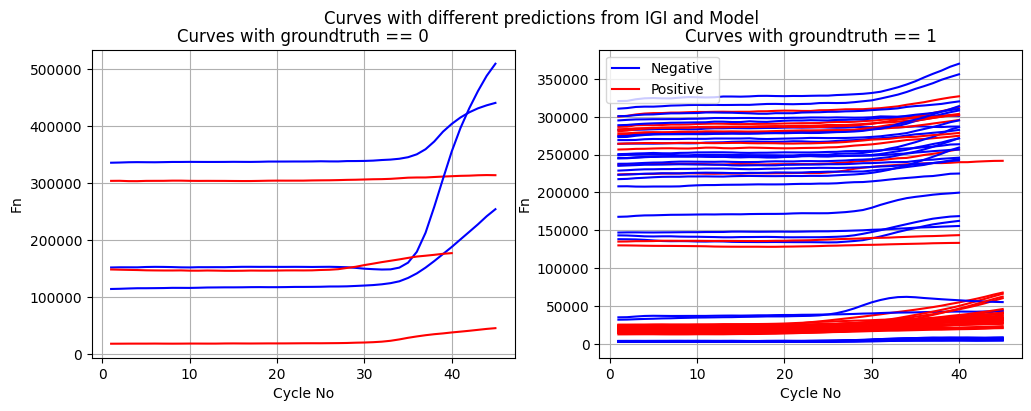

In [24]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
for idx in diff_df.curve_idx:
    df = diff_df[diff_df.curve_idx == idx]
    x = join_df.loc[join_df.curve_idx == idx, 'cycle_no']
    y = join_df.loc[join_df.curve_idx == idx, 'Fn']
    if df['groundtruth_label'].values == 0:    
        if df['matched_pred'].values == 0:
            print(idx)
            axes[0].plot(x,y, color = 'blue')
        else:
            axes[0].plot(x,y, color = 'red')
    else:
        if df['matched_pred'].values == 0:
            axes[1].plot(x,y, color = 'blue')
        else:
            axes[1].plot(x,y, color = 'red')

axes[0].set_xlabel('Cycle No')
axes[0].set_ylabel('Fn')
axes[0].set_title('Curves with groundtruth == 0')
axes[0].grid()

axes[1].plot(1,1,color = 'blue', label = 'Negative')
axes[1].plot(1,1,color = 'red', label = 'Positive')
axes[1].set_xlabel('Cycle No')
axes[1].set_ylabel('Fn')
axes[1].set_title('Curves with groundtruth == 1')
axes[1].grid()
axes[1].legend()
fig.suptitle('Curves with different predictions from IGI and Model')
plt.show()

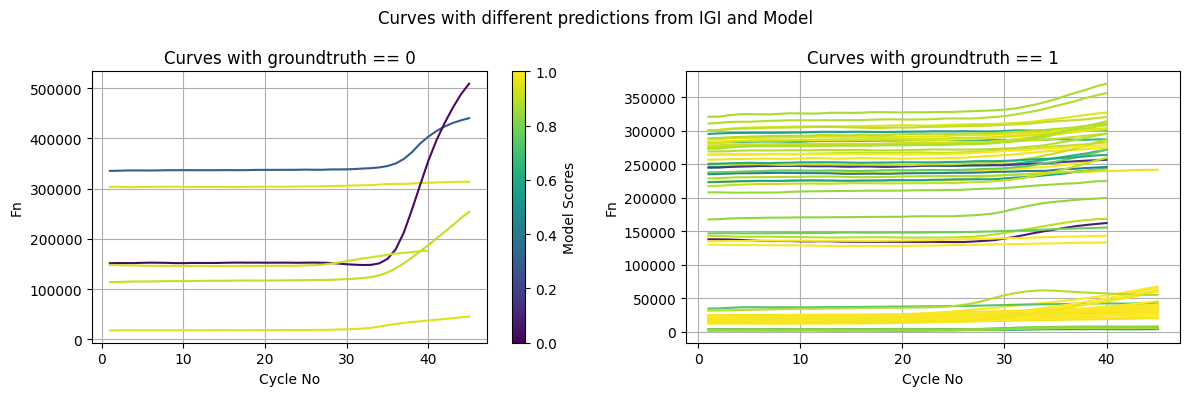

In [25]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
cmap = plt.get_cmap('viridis')  # You can choose a different colormap
color_vals = diff_df.outputs.to_list()
curve_ids = diff_df.curve_idx.to_list()
for i in range(diff_df.shape[0]): 
    x = join_df.loc[join_df.curve_idx == curve_ids[i],'cycle_no']
    y = join_df.loc[join_df.curve_idx == curve_ids[i],'Fn']

    color1 = cmap(color_vals[i])
    if diff_df.loc[diff_df.curve_idx == curve_ids[i], 'groundtruth_label'].values == 0:
        axes[0].plot(x,y, color = color1, label = 'Model predicts negative')
    else:
        axes[1].plot(x,y, color = color1, label = 'Model predicts negative')
    
axes[0].set_xlabel('Cycle No')
axes[0].set_ylabel('Fn')
axes[0].set_title('Curves with groundtruth == 0')
axes[0].grid()

axes[1].set_xlabel('Cycle No')
axes[1].set_ylabel('Fn')
axes[1].set_title('Curves with groundtruth == 1')
axes[1].grid()

# Customize the colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = plt.colorbar(sm, label='Model Scores', ax = axes[0])
fig.suptitle('Curves with different predictions from IGI and Model')
plt.tight_layout()
plt.show()

In [26]:
val_sample_df = (val_pred_df[['curve_idx','encoded_igi_call','matched_pred']]
 .merge(join_df[['curve_idx','sample_id', 'target','sample_type']]
        .loc[~join_df.target.isin(['MS2','RnaseP'])]
        .drop_duplicates(), how='inner', on='curve_idx')
 .groupby('sample_id')
 .filter(lambda x: len(x) > 1))

val_sample_df.loc[:,'sample_type'] = val_sample_df.sample_type.replace({'Negative Control (qPCR)': 0,
                                                                        'Human Normal Negative Control (Extraction)': 0,
                                                                        'Positive Control (qPCR)': 1})
val_sample_pred = (val_sample_df
 .groupby('sample_id')[['matched_pred','encoded_igi_call']]
 .apply('mean').reset_index())

print('Agreement rate between genes in model prediction is: ', (sum(val_sample_pred.matched_pred.isin([0,1]))/val_sample_pred.shape[0]))
print('Agreement rate between genes in IGI prediction is: ', (sum(val_sample_pred.encoded_igi_call.isin([0,1]))/val_sample_pred.shape[0]))

Agreement rate between genes in model prediction is:  0.9766355140186916
Agreement rate between genes in IGI prediction is:  0.985981308411215


## Test set

In [13]:
tn, fp, fn, tp = confusion_matrix(test_pred_df.groundtruth_label, test_pred_df.encoded_igi_call).ravel()

igi_precision = tp/(fp + tp)
igi_recall = tp/(tp + fn)
igi_specificity = tn/(tn + fp)
igi_f1 = 2*tp/(2*tp + fp + fn)

igi_neg_pred = sum(test_pred_df.encoded_igi_call == 0)

print('True negative, false positive, false negative, true positive:', tn, fp, fn, tp)
print('IGI negative predictions:', igi_neg_pred)
print('IGI precision score:', igi_precision)
print('IGI recall score:', igi_recall)
print('IGI specificity:', igi_specificity)
print('IGI F1:', igi_f1)

True negative, false positive, false negative, true positive: 621 0 247 5276
IGI negative predictions: 868
IGI precision score: 1.0
IGI recall score: 0.955277928661959
IGI specificity: 1.0
IGI F1: 0.9771275118066488


In [14]:

# Define the number of true negatives and false negatives for different thresholds
# Replace these values with your actual data
thresholds = np.linspace(0.1, 1, 1000)
neg_preds, tnrs, precisions, recalls = [], [], [], []
for thres in thresholds:
    pred = 1*(test_pred_df.outputs >= thres)
    neg_preds.append(sum(pred == 0))
    tn, fp, fn, tp = confusion_matrix(test_pred_df.groundtruth_label, pred).ravel()
    # tnrs.append(sum((test_pred_df.groundtruth_label == 0) & (test_pred_df.groundtruth_label == pred)))
    # precisions.append(precision_score(test_pred_df.groundtruth_label, pred))
    # recalls.append(recall_score(test_pred_df.groundtruth_label, pred))

threshold_idx = neg_preds.index(868)
matched_thres = thresholds[threshold_idx]
matched_pred = 1*(test_pred_df.outputs >= matched_thres)
tn, fp, fn, tp = confusion_matrix(test_pred_df.groundtruth_label, matched_pred).ravel()

precision = tp/(fp + tp)
recall = tp/(tp + fn)
specificity = tn/(tn + fp)
f1 = 2*tp/(2*tp + fp + fn)
print('Threshold to match IGI true negatives:', matched_thres)
print('True negative, false positive, false negative, true positive:', tn, fp, fn, tp)
print('With matching threshold, model precision:', precision)
print('With matching threshold, model recall:', recall)
print('With matching threshold, model specificity:', specificity)
print('With matching threshold, model F1:', f1)

# # Create a plot
# plt.figure(figsize=(8, 6))
# plt.plot(thresholds, precisions, label='Model Precision')
# plt.plot(thresholds, recalls, label='Model Recall')
# plt.axhline(igi_precision, color = 'black', linestyle='--')
# plt.annotate(f'IGI Precision = {igi_precision}', xy=(0.1, igi_precision), xytext=(0.15, igi_precision))
# plt.axvline(thresholds[threshold_idx], color = 'black', linestyle='--')
# plt.axhline(recalls[threshold_idx], color = 'black', linestyle='--')
# plt.annotate(f'Model Recall = {recalls[threshold_idx]}', xy=(0.1, recalls[threshold_idx]), xytext=(thresholds[50], recalls[threshold_idx]*1.001))
# plt.annotate(f'IGI Recall = {igi_recall}', xy=(0.1, recalls[threshold_idx]), xytext=(thresholds[50], recalls[threshold_idx]*0.996))
# plt.xlabel("Threshold")
# plt.ylabel("Rate")
# plt.ylim((0.85,1.02))
# plt.title("Precision and Recall vs. Threshold on Test Set")
# plt.legend(loc='lower left')
# plt.grid(True)
# plt.show()


Threshold to match IGI true negatives: 0.9351351351351351
True negative, false positive, false negative, true positive: 619 2 249 5274
With matching threshold, model precision: 0.9996209249431387
With matching threshold, model recall: 0.9549158066268333
With matching threshold, model specificity: 0.9967793880837359
With matching threshold, model F1: 0.97675710713955


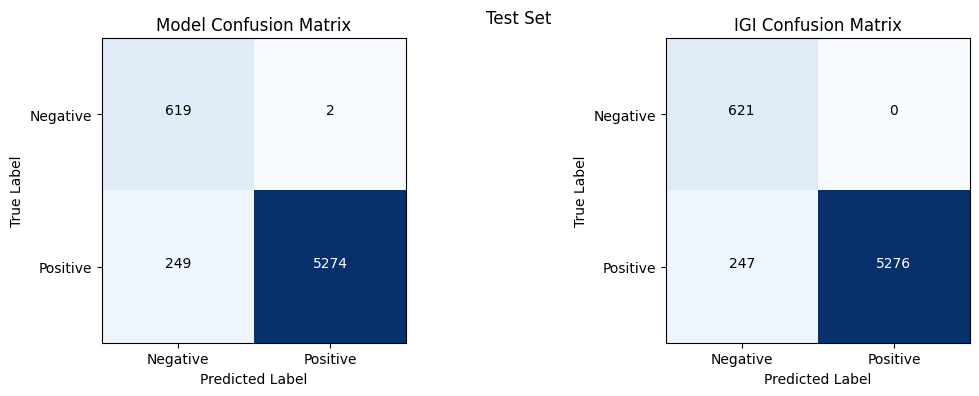

In [15]:
matched_preds = 1*(test_pred_df.outputs >= matched_thres)
# Calculate the confusion matrix
cm1 = confusion_matrix(test_pred_df.groundtruth_label, matched_preds)
cm2 = confusion_matrix(test_pred_df.groundtruth_label, test_pred_df.encoded_igi_call)

# Define class labels (replace with your class labels)
class_labels = ["Negative", "Positive"]

# Create a heatmap of the confusion matrix
fig, axes = plt.subplots(1,2, figsize=(12,4))

axes[0].imshow(cm1, interpolation='nearest', cmap=plt.cm.Blues)
axes[0].set_title("Model Confusion Matrix")
axes[0].set_xticks(np.arange(len(class_labels)))
axes[0].set_yticks(np.arange(len(class_labels)))
axes[0].set_xticklabels(class_labels)
axes[0].set_yticklabels(class_labels)

thresh = cm1.max() / 2.
for i, j in itertools.product(range(cm1.shape[0]), range(cm1.shape[1])):
    axes[0].text(j, i, format(cm1[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm1[i, j] > thresh else "black")

axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Plot the second confusion matrix
axes[1].imshow(cm2, interpolation='nearest', cmap=plt.cm.Blues)
axes[1].set_title("IGI Confusion Matrix")
axes[1].set_xticks(np.arange(len(class_labels)))
axes[1].set_yticks(np.arange(len(class_labels)))
axes[1].set_xticklabels(class_labels)
axes[1].set_yticklabels(class_labels)

thresh = cm2.max() / 2.
for i, j in itertools.product(range(cm2.shape[0]), range(cm2.shape[1])):
    axes[1].text(j, i, format(cm2[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm2[i, j] > thresh else "black")

axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
fig.suptitle('Test Set')
plt.show()


In [16]:
test_pred_df.loc[:,['matched_pred']] = matched_preds
print('Model confusion matrix')
print(classification_report(test_pred_df.groundtruth_label, round(test_pred_df.matched_pred)))
print('IGI confusion matrix')
print(classification_report(test_pred_df.groundtruth_label, round(test_pred_df.encoded_igi_call)))

Model confusion matrix
              precision    recall  f1-score   support

           0       0.71      1.00      0.83       621
           1       1.00      0.95      0.98      5523

    accuracy                           0.96      6144
   macro avg       0.86      0.98      0.90      6144
weighted avg       0.97      0.96      0.96      6144

IGI confusion matrix
              precision    recall  f1-score   support

           0       0.72      1.00      0.83       621
           1       1.00      0.96      0.98      5523

    accuracy                           0.96      6144
   macro avg       0.86      0.98      0.91      6144
weighted avg       0.97      0.96      0.96      6144



In [17]:

diff_df = test_pred_df.loc[test_pred_df.encoded_igi_call != test_pred_df.matched_pred]
print('Number of different curves:', diff_df.shape[0])
diff_df.head()

Number of different curves: 116


,curve_idx,groundtruth_label,encoded_igi_call,outputs,matched_pred
279,10573,0,0,0.935136,1
322,39401,0,0,0.943422,1
390,103226,1,1,0.200920,0
393,103250,1,1,0.870246,0
441,4922,1,1,0.849216,0


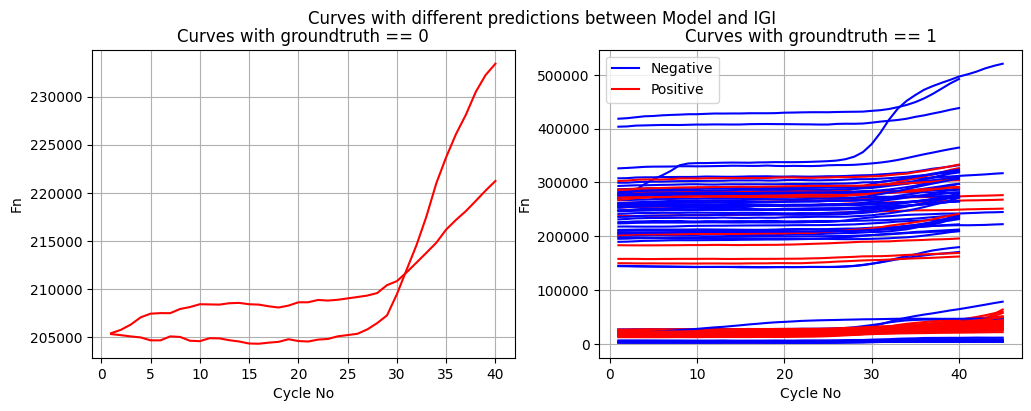

In [18]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
for idx in diff_df.curve_idx:
    df = diff_df[diff_df.curve_idx == idx]
    x = join_df.loc[join_df.curve_idx == idx, 'cycle_no']
    y = join_df.loc[join_df.curve_idx == idx, 'Fn']
    if df['groundtruth_label'].values == 0:    
        if df['matched_pred'].values == 0:
            axes[0].plot(x,y, color = 'blue')
        else:
            axes[0].plot(x,y, color = 'red')
    else:
        if df['matched_pred'].values == 0:
            axes[1].plot(x,y, color = 'blue')
        else:
            axes[1].plot(x,y, color = 'red')

axes[0].set_xlabel('Cycle No')
axes[0].set_ylabel('Fn')
axes[0].set_title('Curves with groundtruth == 0')
axes[0].grid()

axes[1].plot(1,1,color = 'blue', label = 'Negative')
axes[1].plot(1,1,color = 'red', label = 'Positive')
axes[1].set_xlabel('Cycle No')
axes[1].set_ylabel('Fn')
axes[1].set_title('Curves with groundtruth == 1')
axes[1].grid()
fig.suptitle('Curves with different predictions between Model and IGI')
plt.legend()
plt.show()

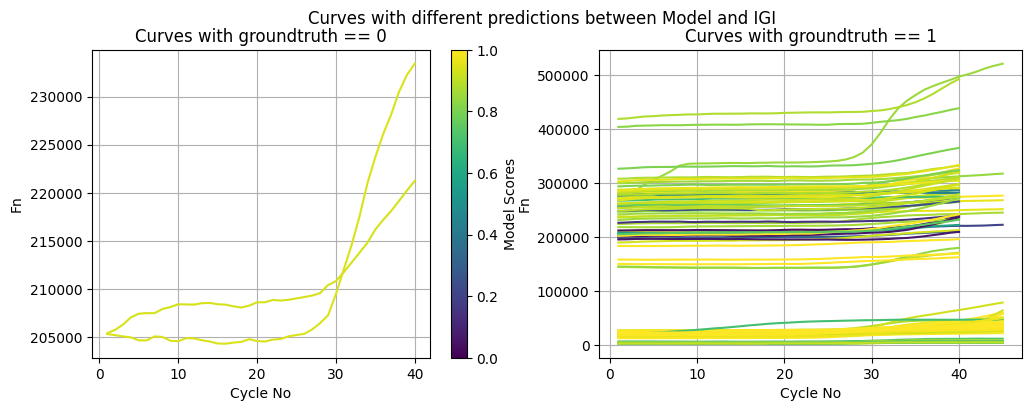

In [19]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
cmap = plt.get_cmap('viridis')  # You can choose a different colormap
color_vals = diff_df.outputs.to_list()
curve_ids = diff_df.curve_idx.to_list()
for i in range(diff_df.shape[0]): 
    x = join_df.loc[join_df.curve_idx == curve_ids[i],'cycle_no']
    y = join_df.loc[join_df.curve_idx == curve_ids[i],'Fn']

    color1 = cmap(color_vals[i])
    if diff_df.loc[diff_df.curve_idx == curve_ids[i], 'groundtruth_label'].values == 0:
        axes[0].plot(x,y, color = color1) #, label = 'Model predicts negative')
    else:
        axes[1].plot(x,y, color = color1) #, label = 'Model predicts negative')
    
axes[0].set_xlabel('Cycle No')
axes[0].set_ylabel('Fn')
axes[0].set_title('Curves with groundtruth == 0')
axes[0].grid()

axes[1].set_xlabel('Cycle No')
axes[1].set_ylabel('Fn')
axes[1].set_title('Curves with groundtruth == 1')
axes[1].grid()

# Customize the colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = plt.colorbar(sm, label='Model Scores', ax=axes[0])
fig.suptitle('Curves with different predictions between Model and IGI')
plt.show()

In [20]:
diff_df_2 = (diff_df
           .merge(join_df[['curve_idx','cycle_no','Fn','target','sample_type','record_type','retest_sample_id_1']], 
                  how = 'inner', on = 'curve_idx'))
diff_df_2.loc[:,'matched_pred_val'] = diff_df_2.matched_pred.replace({1:'Positive',0:'Negative'})
diff_df_2.head()


,curve_idx,groundtruth_label,encoded_igi_call,outputs,matched_pred,cycle_no,Fn,target,sample_type,record_type,retest_sample_id_1,matched_pred_val
0,10573,0,0,0.935136,1,1,205379.90,MS2,Negative Control (qPCR),Control Sample,,Positive
1,10573,0,0,0.935136,1,2,205733.64,MS2,Negative Control (qPCR),Control Sample,,Positive
2,10573,0,0,0.935136,1,3,206280.72,MS2,Negative Control (qPCR),Control Sample,,Positive
3,10573,0,0,0.935136,1,4,207030.38,MS2,Negative Control (qPCR),Control Sample,,Positive
4,10573,0,0,0.935136,1,5,207409.84,MS2,Negative Control (qPCR),Control Sample,,Positive


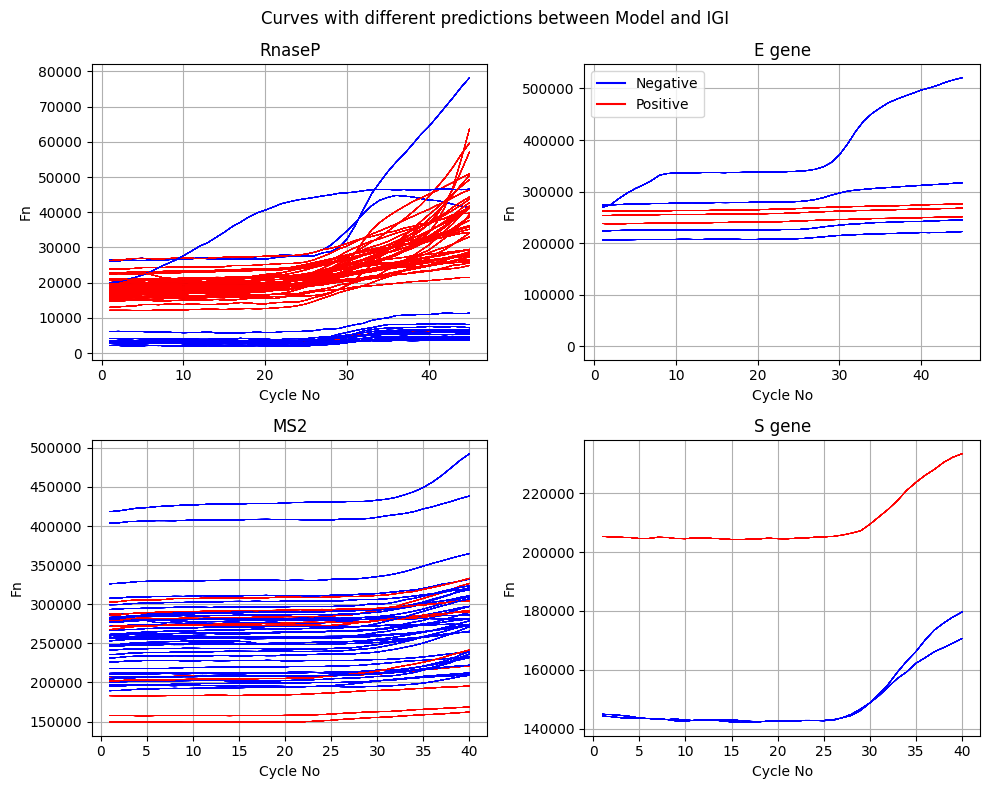

In [21]:
fig, axes = plt.subplots(2,2, figsize=(10,8))
for idx in diff_df_2.curve_idx:
    df = diff_df_2[diff_df_2.curve_idx == idx]
    x = df.cycle_no
    y = df.Fn
    if all(df.loc[df.cycle_no == 1, 'target'] == 'RnaseP'):
        if all(df['matched_pred'].values == 0):
            axes[0,0].plot(x,y, color = 'blue', lw = 0.5)
        else:
            axes[0,0].plot(x,y, color = 'red', lw = 0.5)

    elif all(df.loc[df.cycle_no == 1, 'target'] == 'E gene'):
        if all(df['matched_pred'].values == 0):
            axes[0,1].plot(x,y, color = 'blue', lw = 0.5)
        else:
            axes[0,1].plot(x,y, color = 'red', lw = 0.5)

    # elif all(df.loc[df.cycle_no == 2, 'target'] == 'N gene'):
    #     if all(df['matched_pred'].values == 0):
    #         axes[0,2].plot(x,y, color = 'blue')
    #     else:
    #         axes[0,2].plot(x,y, color = 'red')

    elif all(df.loc[df.cycle_no == 2, 'target'] == 'MS2'):
        if all(df['matched_pred'].values == 0):
            axes[1,0].plot(x,y, color = 'blue', lw = 0.5)
        else:
            axes[1,0].plot(x,y, color = 'red', lw = 0.5)

    elif all(df.loc[df.cycle_no == 2, 'target'] == 'S gene'):
        if all(df['matched_pred'].values == 0):
            axes[1,1].plot(x,y, color = 'blue', lw = 0.5)
        else:
            axes[1,1].plot(x,y, color = 'red', lw = 0.5)

    # elif all(df.loc[df.cycle_no == 2, 'target'] == 'ORF1ab'):
    #     if df['matched_pred'].values == 0:
    #         axes[1,2].plot(x,y, color = 'blue')
    #     else:
    #         axes[1,2].plot(x,y, color = 'red')

targets = [['RnaseP','E gene'],['MS2','S gene']]
for r,c in itertools.product([0,1], [0,1]):
    axes[r,c].set_xlabel('Cycle No')
    axes[r,c].set_ylabel('Fn')
    axes[r,c].set_title(targets[r][c])
    axes[r,c].grid()

axes[0,1].plot(1,1,color = 'blue', label = 'Negative')
axes[0,1].plot(1,1,color = 'red', label = 'Positive')
axes[0,1].legend()
fig.suptitle('Curves with different predictions between Model and IGI')
plt.tight_layout()
plt.show()


## Latent clustering

### Full test data

In [90]:
# load latent
with open('../data/model_outputs/fusion_seq_latent.pkl', 'rb') as file:
    latent_dict = pkl.load(file)

# diff_ids = pd.Series(latent_dict['curve_ids']).isin(diff_df.curve_idx)
# latent = latent_dict['latent'][diff_ids[diff_ids].index,:]

diff_ids = pd.Series(latent_dict['curve_ids']).isin(gru_test_pred.curve_idx)
latent = latent_dict['latent'][diff_ids[diff_ids].index,:]


In [91]:
df = (join_df[['curve_idx','cycle_no','Fn','target','sample_type','record_type','retest_sample_id_1']]
                       .groupby(['curve_idx','target','sample_type','record_type','retest_sample_id_1'])
                       .cycle_no.max().reset_index())
df.loc[:,'test_kit'] = 'Thermo'
df.loc[df.cycle_no == 45,'test_kit'] = 'LuNER'
df.loc[:, 'retest'] = df.retest_sample_id_1 != ' '
test_pred_2 = (test_pred_df
               .merge(df,how = 'inner', on = 'curve_idx'))

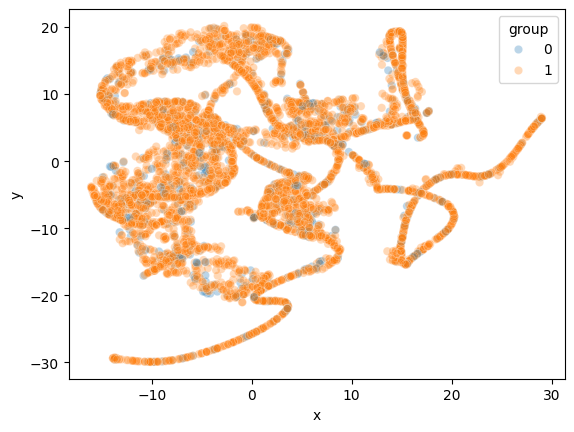

In [92]:
tsne = TSNE(n_components=3, random_state=42)
X_tsne = tsne.fit_transform(latent)
tsne.kl_divergence_
tsne_df = pd.DataFrame({'x': X_tsne[:,0],
                        'y': X_tsne[:,1],
                        'z': X_tsne[:,2],
                        'group': test_pred_2.matched_pred})
sns.scatterplot(x='x', y='y', hue='group', alpha = 0.3, data = tsne_df)
plt.show()

Explained variation per principal component: [0.6292761  0.36341894 0.00382539]


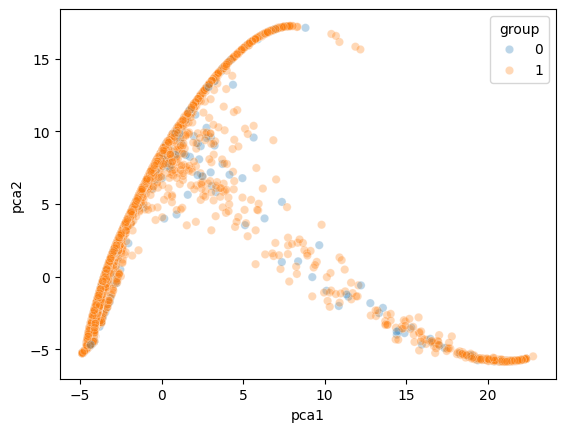

In [93]:
pca = PCA(n_components=3)
pca_result = pca.fit_transform(latent)

pca_df = pd.DataFrame({'pca1': pca_result[:,0],
                   'pca2': pca_result[:,1],
                   'pca3': pca_result[:,2],
                   'group': test_pred_2.matched_pred})

print('Explained variation per principal component: {}'.format(pca.explained_variance_ratio_))
sns.scatterplot(x='pca1', y='pca2', hue='group', alpha = 0.3, data = pca_df)
plt.show()


### False predicted curves

In [94]:
fp_pred = (test_pred_2.matched_pred == 1) & (test_pred_2.matched_pred != test_pred_2.groundtruth_label)
fn_pred = (test_pred_2.matched_pred == 0) & (test_pred_2.matched_pred != test_pred_2.groundtruth_label)
false_pred = test_pred_2[(test_pred_2.matched_pred != test_pred_2.groundtruth_label)]

false_ids = pd.Series(latent_dict['curve_ids']).isin(false_pred.curve_idx)
false_pred_latent = latent_dict['latent'][false_ids[false_ids].index,:]


KL divergence: 0.038081880658864975


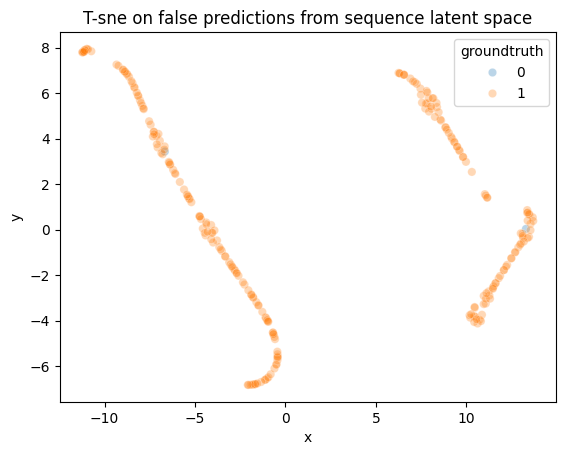

In [97]:
tsne = TSNE(n_components=3, random_state=42)
X_tsne = tsne.fit_transform(false_pred_latent)
print('KL divergence:', tsne.kl_divergence_)
tsne_df = pd.DataFrame({'x': X_tsne[:,0],
                        'y': X_tsne[:,1],
                        'z': X_tsne[:,2],
                        'groundtruth': false_pred.groundtruth_label})
sns.scatterplot(x='x', y='y', hue='groundtruth', alpha = 0.3, data = tsne_df)
plt.title('T-sne on false predictions from sequence latent space')
plt.show()

Explained variation per principal component: [0.81642616 0.18172878 0.00111049]


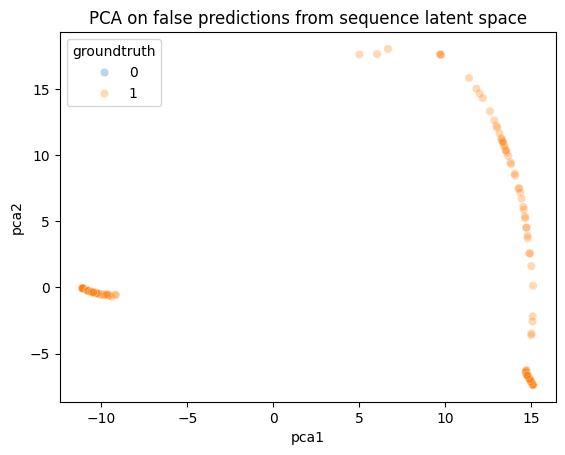

In [98]:
pca = PCA(n_components=3)
pca_result = pca.fit_transform(false_pred_latent)

pca_df = pd.DataFrame({'pca1': pca_result[:,0],
                   'pca2': pca_result[:,1],
                   'pca3': pca_result[:,2],
                   'groundtruth': false_pred.groundtruth_label})

print('Explained variation per principal component: {}'.format(pca.explained_variance_ratio_))
sns.scatterplot(x='pca1', y='pca2', hue='groundtruth', alpha = 0.3, data = pca_df)
plt.title('PCA on false predictions from sequence latent space')
plt.show()

### False negatives

In [59]:
# fp_pred = (test_pred_2.matched_pred == 1) & (test_pred_2.matched_pred != test_pred_2.groundtruth_label)
# fn_pred = (test_pred_2.matched_pred == 0) & (test_pred_2.matched_pred != test_pred_2.groundtruth_label)
false_neg_pred = test_pred_2[(test_pred_2.matched_pred != test_pred_2.groundtruth_label) & (test_pred_2.matched_pred == 0)]

false_neg_ids = pd.Series(latent_dict['curve_ids']).isin(false_neg_pred.curve_idx)
false_neg_pred_latent = latent_dict['latent'][false_neg_ids[false_neg_ids].index,:]


KL divergence: 0.03621528670191765


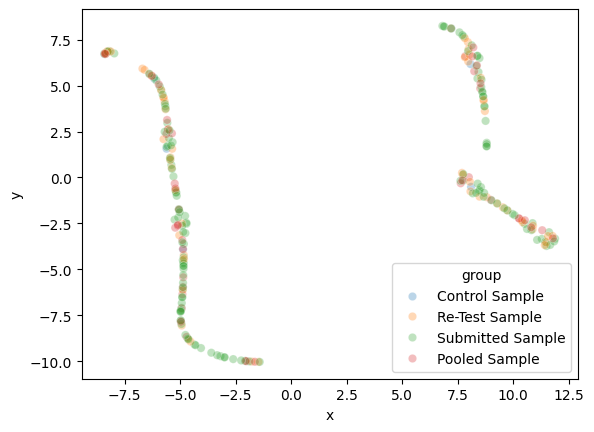

In [60]:
tsne = TSNE(n_components=3, random_state=42)
X_tsne = tsne.fit_transform(false_neg_pred_latent)
print('KL divergence:', tsne.kl_divergence_)
tsne_df = pd.DataFrame({'x': X_tsne[:,0],
                        'y': X_tsne[:,1],
                        'z': X_tsne[:,2],
                        'group': false_neg_pred.record_type})
sns.scatterplot(x='x', y='y', hue='group', alpha = 0.3, data = tsne_df)
plt.show()

Explained variation per principal component: [0.81929916 0.17884453 0.00112309]


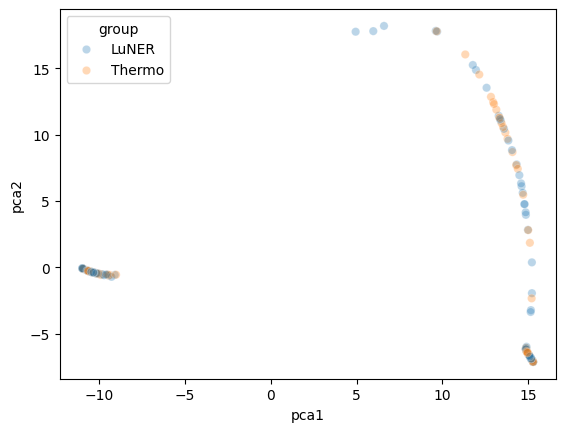

In [61]:
pca = PCA(n_components=3)
pca_result = pca.fit_transform(false_neg_pred_latent)

pca_df = pd.DataFrame({'pca1': pca_result[:,0],
                   'pca2': pca_result[:,1],
                   'pca3': pca_result[:,2],
                   'group': false_neg_pred.test_kit})

print('Explained variation per principal component: {}'.format(pca.explained_variance_ratio_))
sns.scatterplot(x='pca1', y='pca2', hue='group', alpha = 0.3, data = pca_df)
plt.show()

In [69]:
test_sample_df = (test_pred_df[['curve_idx','encoded_igi_call','matched_pred']]
 .merge(join_df[['curve_idx','sample_id', 'target','sample_type']]
        .loc[~join_df.target.isin(['MS2','RnaseP'])]
        .drop_duplicates(), how='inner', on='curve_idx')
 .groupby('sample_id')
 .filter(lambda x: len(x) > 1))

test_sample_df.loc[:,'sample_type'] = test_sample_df.sample_type.replace({'Negative Control (qPCR)': 0,
                                                                        'Human Normal Negative Control (Extraction)': 0,
                                                                        'Positive Control (qPCR)': 1})
test_sample_pred = (test_sample_df
 .groupby('sample_id')[['matched_pred','encoded_igi_call']]
 .apply('mean').reset_index())

print('Agreement rate between genes in Model prediction is: ', (sum(test_sample_pred.matched_pred.isin([0,1]))/test_sample_pred.shape[0]))
print('Agreement rate between genes in IGI prediction is: ', (sum(test_sample_pred.encoded_igi_call.isin([0,1]))/test_sample_pred.shape[0]))

Agreement rate between genes in Model prediction is:  0.9758620689655172
Agreement rate between genes in IGI prediction is:  0.9896551724137931


### Other genes validation